# Deep NLP: Text Classification on Custom Dataset (LSTM)

In this notebook, I build a deep learning model to classify text samples using a custom dataset (`Sheet_1.csv`). The goal is to apply end-to-end NLP: cleaning, tokenization, sequence modeling with LSTMs, and evaluation on a held-out test set.

## Key questions

- What is the distribution of classes in the dataset?
- Which preprocessing steps (cleaning, tokenization, sequence length) work best for this text?
- How well can an LSTM-based deep learning model classify the text compared to a simple baseline (e.g., TF-IDF + Logistic Regression)?


# 1 Imports & data loading

Here I import standard libraries for data handling, visualization and deep learning (TensorFlow / Keras), then load the `Sheet_1.csv` dataset and inspect its basic structure.

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
    

In [39]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root, files)

/kaggle/input []
/kaggle/input/deep-nlp-text-classification-on-custom ['Sheet_1.csv']


# Load data

In [40]:
# Load data
import pandas as pd

df = pd.read_csv('/kaggle/input/deep-nlp-text-classification-on-custom/Sheet_1.csv')
df.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,response_id,class,response_text,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,response_1,not_flagged,I try and avoid this sort of conflict,NaN,NaN,NaN,NaN,NaN
1,response_2,flagged,Had a friend open up to me about his mental ad...,NaN,NaN,NaN,NaN,NaN
2,response_3,flagged,I saved a girl from suicide once. She was goin...,NaN,NaN,NaN,NaN,NaN
3,response_4,not_flagged,i cant think of one really...i think i may hav...,NaN,NaN,NaN,NaN,NaN
4,response_5,not_flagged,Only really one friend who doesn't fit into th...,,NaN,NaN,NaN,NaN


In [41]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,response_id,class,response_text,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,response_1,not_flagged,I try and avoid this sort of conflict,NaN,NaN,NaN,NaN,NaN
1,response_2,flagged,Had a friend open up to me about his mental ad...,NaN,NaN,NaN,NaN,NaN
2,response_3,flagged,I saved a girl from suicide once. She was goin...,NaN,NaN,NaN,NaN,NaN
3,response_4,not_flagged,i cant think of one really...i think i may hav...,NaN,NaN,NaN,NaN,NaN
4,response_5,not_flagged,Only really one friend who doesn't fit into th...,,NaN,NaN,NaN,NaN


In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   response_id    80 non-null     object 
 1   class          80 non-null     object 
 2   response_text  80 non-null     object 
 3   Unnamed: 3     2 non-null      object 
 4   Unnamed: 4     0 non-null      float64
 5   Unnamed: 5     1 non-null      object 
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     1 non-null      object 
dtypes: float64(2), object(6)
memory usage: 5.1+ KB


In [48]:
print(df.columns)


Index(['response_id', 'class', 'response_text', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')


In [49]:
df['class'].value_counts(normalize=True)



class
not_flagged    0.6875
flagged        0.3125
Name: proportion, dtype: float64

# 2 Text cleaning function

## 2. Text preprocessing

I convert all text to lowercase, remove URLs, mentions, special characters and extra spaces, and store the result in a new `clean_text` column. This simplifies the vocabulary for the neural network.


In [63]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)        # remove URLs
    text = re.sub(r"@\w+|#\w+", " ", text)             # remove mentions/hashtags
    text = re.sub(r"[^a-z\s]", " ", text)              # keep only letters
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['response_text'].astype(str).apply(clean_text)
df[['response_id', 'response_text', 'clean_text']].head()



,response_id,response_text,clean_text
0,response_1,I try and avoid this sort of conflict,i try and avoid this sort of conflict
1,response_2,Had a friend open up to me about his mental ad...,had a friend open up to me about his mental ad...
2,response_3,I saved a girl from suicide once. She was goin...,i saved a girl from suicide once she was going...
3,response_4,i cant think of one really...i think i may hav...,i cant think of one really i think i may have ...
4,response_5,Only really one friend who doesn't fit into th...,only really one friend who doesn t fit into th...


In [64]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# clean_text column
df['clean_text'] = df['response_text'].astype(str).apply(clean_text)

# label column (agar tum 'class' ko hi label banana chahte ho)
df['label'] = df['class']


## 3. Train–validation split

The dataset is split into training and validation sets using an 80/20 ratio with stratification to preserve the class distribution.


In [66]:
from sklearn.model_selection import train_test_split

X = df['clean_text'].values
y = df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [67]:
len(X), len(X_train), len(X_val)


(80, 64, 16)

In [68]:
print(X_train[:5])
print(y_train[:5])


['the one person i ever talked to it was because we were both going through the same thing us talking together helped it was important to realize you aren t alone'
 'when my best friends mom past away from od ing when he was in grade'
 'sometimes i ll calm my friends down after bad stuff happens'
 'my now girlfriend used to have serious addiction troubles before we started dating and felt as though her addiction defined her as a person she thought that all people saw when they looked at her was the addiction i spent many nights with her talking and letting her vent i was one of the only people supporting her and she felt as though i could help because i had been in her spot'
 'helped friends through stuff']
['not_flagged' 'flagged' 'not_flagged' 'flagged' 'not_flagged']


## 4. Tokenization and padding

I tokenize the cleaned text into integer sequences and pad them to a fixed length (`max_len`). This produces a dense numeric representation suitable as input to an LSTM model.


In [69]:
max_words = 20000    # vocabulary size
max_len = 100        # max sequence length (tune after checking text length)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
vocab_size


588

## 5. Deep NLP model: BiLSTM

The model uses an Embedding layer to learn dense word vectors, followed by a Bidirectional LSTM to capture context from both directions, and fully connected layers for classification.



In [70]:
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # for binary; use Dense(num_classes, 'softmax') for multi-class
])

model.compile(
    loss='binary_crossentropy',      # use 'sparse_categorical_crossentropy' for multi-class
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-01-01 12:09:05.969582: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 6 Training

## 6. Training and learning curves

I train the BiLSTM model for several epochs and monitor training vs validation accuracy and loss to detect underfitting or overfitting.


In [73]:
print(type(y_train), y_train[:5])
print(y_train.dtype)


<class 'numpy.ndarray'> ['not_flagged' 'flagged' 'not_flagged' 'flagged' 'not_flagged']
object


In [77]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1) Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])   # 'flagged' / 'not_flagged' -> 0/1

# 2) Split
X = df['clean_text'].values
y = y_encoded

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Tokenizer + padding jaise pehle kar rahe ho
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')


In [78]:
print(type(y_train), y_train.dtype, y_train[:5])
# numpy.ndarray int64 [...0,1,...] hona chahiye


<class 'numpy.ndarray'> int64 [1 0 1 0 1]


In [79]:
vocab_size = len(tokenizer.word_index) + 1

model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

batch_size = 64
epochs = 10

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7031 - loss: 0.6865 - val_accuracy: 0.6875 - val_loss: 0.6664
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7031 - loss: 0.6635 - val_accuracy: 0.6875 - val_loss: 0.6484
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7031 - loss: 0.6429 - val_accuracy: 0.6875 - val_loss: 0.6334
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7031 - loss: 0.6245 - val_accuracy: 0.6875 - val_loss: 0.6236
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7031 - loss: 0.6099 - val_accuracy: 0.6875 - val_loss: 0.6228
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7031 - loss: 0.6026 - val_accuracy: 0.6875 - val_loss: 0.6345
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7031 - loss: 0.6061 - val_accuracy: 0.6875 - val_loss: 0.6457
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7031 - loss: 0.6126 - val_accuracy: 0.6875 - val_loss: 0.6450
Epoch 

In [80]:
batch_size = 64
epochs = 10

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.7188 - loss: 0.6038 - val_accuracy: 0.6875 - val_loss: 0.6257
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7188 - loss: 0.6015 - val_accuracy: 0.6875 - val_loss: 0.6228
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7188 - loss: 0.6010 - val_accuracy: 0.6875 - val_loss: 0.6217
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7188 - loss: 0.6015 - val_accuracy: 0.6875 - val_loss: 0.6214
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7188 - loss: 0.6023 - val_accuracy: 0.6875 - val_loss: 0.6215
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7188 - loss: 0.6028 - val_accuracy: 0.6875 - val_loss: 0.6216
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7188 - loss: 0.6029 - val_accuracy: 0.6875 - val_loss: 0.6215
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7188 - loss: 0.6025 - val_accuracy: 0.6875 - val_loss:

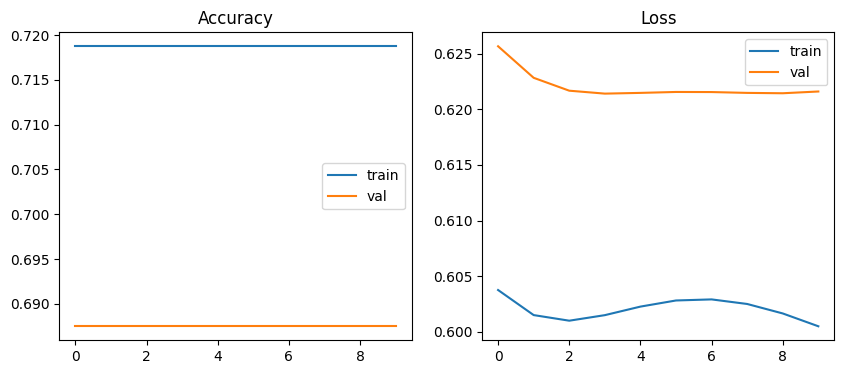

In [81]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()


## 7. Evaluation

I evaluate the model using precision, recall, F1-score and a confusion matrix to understand performance per class and common misclassifications.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.69      1.00      0.81        11

    accuracy                           0.69        16
   macro avg       0.34      0.50      0.41        16
weighted avg       0.47      0.69      0.56        16



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


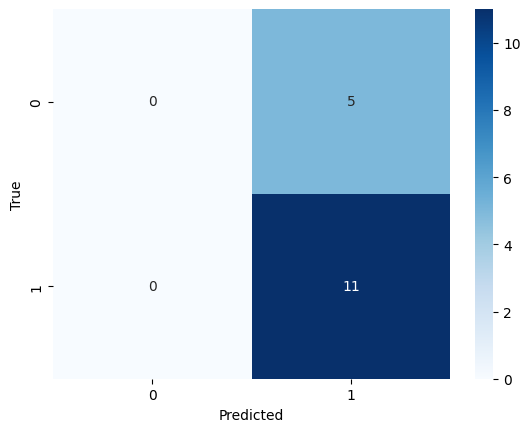

In [82]:
y_val_pred_proba = model.predict(X_val_pad)
y_val_pred = (y_val_pred_proba >= 0.5).astype(int).ravel()

print(classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



## 8. Testing on custom examples

Finally, I create a small helper function to run the model on custom text and inspect predicted sentiment / class, making the model easier to demo.


In [83]:
def predict_text(text):
    ct = clean_text(text)
    seq = tokenizer.texts_to_sequences([ct])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    proba = model.predict(pad)[0][0]
    label = 1 if proba >= 0.5 else 0
    return label, float(proba)

example = "This movie was absolutely fantastic and I loved it."
predict_text(example)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


(1, 0.6946335434913635)